# Example simulations of toy metabolic networks

This notebook runs evolutionary simulation of two toy metabolic networks described in the text: the original toy network and the augmented toy network with five genes for reaction 2.

The functions to run and analyze a simulation are included in the evcm module.

In [1]:
import evcm

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl

# Run simulation of toy network

The matrices for the original toy network are saved as a .npz file in the networks folder. $a_{max}$ is infinite for all bounds, so uimmutable and limmutable are empty lists.

In [3]:
toy_directory = './networks/toynet.npz'

toy_mats = np.load(toy_directory)
S = toy_mats['S']; beta = toy_mats['beta']
Au = toy_mats['Au']; Al = toy_mats['Al']
Gu = toy_mats['Gu']; Gl = toy_mats['Gl']
uimmutable=[list(i) for i in toy_mats['uimmutable']]; limmutable=[list(i) for i in toy_mats['limmutable']]

The key hyperparameters mentioned in the supplement are assigned below.

In [4]:
#Hyperparameters mentioned in the supplement
_T_ = 30001 #Length of simulation
_N_ = 10000000 #Population size
_ms_ = 0.1 #Mutation scale
_em_ = 1 #Expected number of mutations per step
_ss_ = 10 #Simulation scale


`run_sim()` is the main function that performs the mutation+fixation/extinction loop. Various utilities for the simulation (generating random matrices, generating mutations, etc.) are included in `evcm.utils`. `run_sim()` takes in more hyperparameters than indicated here. These hyperparameters are related to different variations of the evolutionary simulations that are not used in the paper and are described in `run_sim()`.

In [5]:
df_flux, df_ubounds,  df_lbounds,  df_biomass, \
         df_umutation,  df_lmutation,  df_neutral, \
         _,  _,  _,  _, \
         _,  _,  _,  _, \
         _ = \
         evcm.sim.run_sim(T=_T_,
                Au=Au,Al=Al,S=S,Gu=Gu,Gl=Gl,beta=beta,
                pop_size=_N_,
                mutate_scale=_ms_, 
                simulation_scale=_ss_,
                expected_mutations=_em_,
                uimmutable=uimmutable,limmutable=limmutable,
                Reaction_labels=['1','2','3','4'],uGene_labels=['1','2','3','4'],lGene_labels=['1','2','3','4'])

0 9.979 [9.98 0.05 9.93 9.93] [ 9.98 10.17 10.06  9.93] [ -9.98 -10.01  -9.94  -9.97] [0. 0. 0. 0.] [0. 0. 0. 0.]


/projectnb/modes/aedanrb/data_analysis_for_papers/CollectiveModes_1/example_notebooks/evcm/utils/utils.py:441: RuntimeWarning: overflow encountered in exp
  prob_fix = (1 - np.exp(-2*s)) / (1 - np.exp(-2*pop_size*s))


10000 144.412 [144.41 100.3   44.11  44.11] [144.63 100.3   44.2   44.11] [-14.29  -7.44 -14.86  -8.81] [165. 109.  48.  56.] [34. 33. 34. 38.]
20000 245.706 [245.71 170.94  74.76  74.76] [245.71 171.35  74.76  74.94] [-13.21  -0.   -13.24  -7.76] [272. 190.  92.  87.] [57. 58. 65. 56.]
30000 379.728 [379.73 265.09 114.64 114.64] [380.08 265.09 114.64 115.07] [ -8.57  -1.44 -17.47  -0.  ] [415. 290. 151. 143.] [90. 85. 93. 92.]


## Basic analysis

We can perform some basic analysis on the the simulation results.

In [6]:
df_flux = pl.from_pandas(df_flux)

### Flux as a function of time steps

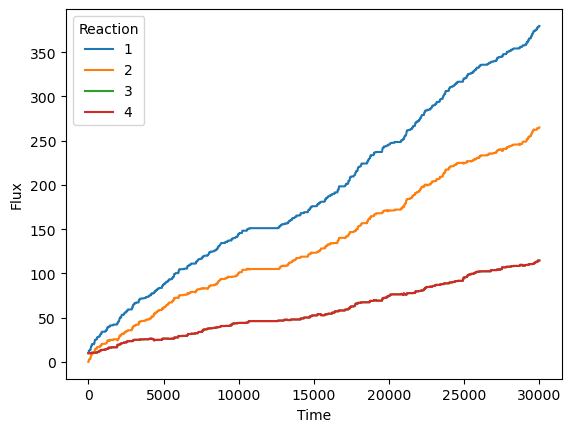

In [7]:
sns.lineplot(df_flux,x='Time',y='Flux',hue='Reaction')
plt.show()

### Normalized, rolling average change in flux

This shows that an EvCM exists, as the direction of evolution is approximately constant.

<Axes: xlabel='Time', ylabel='Flux'>

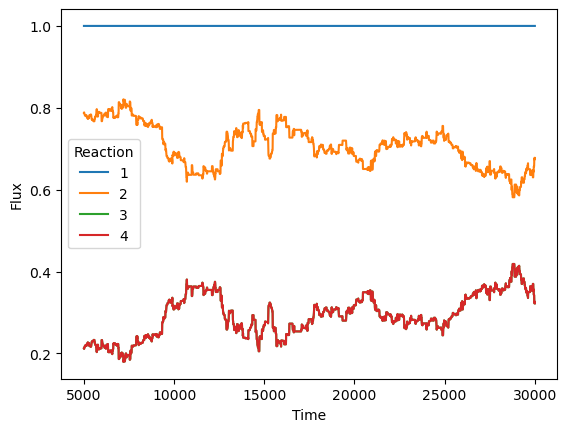

In [8]:
sns.lineplot(
df_flux.with_columns((pl.col('Flux').diff().rolling_mean(window_size=500)).over('Reaction')).\
        with_columns((pl.col('Flux')/pl.col('Flux').max()).over('Time')).drop_nulls(),
        x='Time',y='Flux',hue='Reaction')

# Run simulation of toy network with 5 genes on reaction 2

Now, we will run a simulation of the toy network when reaction 2 can be catalyzed by five genes, as described in the main text.

In [9]:
toy_5gene_directory = './networks/toynet_5gene.npz'

toy_5gene_mats = np.load(toy_5gene_directory)
S_5gene = toy_5gene_mats['S']; beta_5gene = toy_5gene_mats['beta']
Au_5gene = toy_5gene_mats['Au']; Al_5gene = toy_5gene_mats['Al']
Gu_5gene = toy_5gene_mats['Gu']; Gl_5gene = toy_5gene_mats['Gl']
Sigmau_5gene = toy_5gene_mats['Sigmau']; Sigmal_5gene = toy_5gene_mats['Sigmal']
uimmutable_5gene=[list(i) for i in toy_5gene_mats['uimmutable']]; limmutable_5gene=[list(i) for i in toy_5gene_mats['limmutable']]

In [10]:
df_flux_5gene, df_ubounds_5gene,  df_lbounds_5gene,  df_biomass_5gene, \
         df_umutation_5gene,  df_lmutation_5gene,  df_neutral_5gene, \
         _,  _,  _,  _, \
         _,  _,  _,  _, \
         _ = \
         evcm.sim.run_sim(T=_T_,
                Au=Au_5gene,Al=Al_5gene,S=S_5gene,Gu=Gu_5gene,Gl=Gl_5gene,beta=beta_5gene,
                pop_size=_N_,
                mutate_scale=_ms_, 
                simulation_scale=_ss_,
                expected_mutations=_em_,
                uimmutable=uimmutable,limmutable=limmutable,
                Reaction_labels=['1','2','3','4'],
                uGene_labels=['1','2a','2b','2c','2d','2e','3','4'],
                lGene_labels=['1','2a','2b','2c','2d','2e','3','4'])

0 9.974 [9.97 0.06 9.92 9.92] [ 9.97 10.04  9.98 10.   10.07  9.9   9.92  9.92] [ -9.98 -10.03  -9.96  -9.91 -10.01 -10.01 -10.08 -10.01] [0. 0. 0. 0. 0. 0. 0. 0.] [0. 0. 0. 0. 0. 0. 0. 0.]


/projectnb/modes/aedanrb/data_analysis_for_papers/CollectiveModes_1/example_notebooks/evcm/utils/utils.py:441: RuntimeWarning: overflow encountered in exp
  prob_fix = (1 - np.exp(-2*s)) / (1 - np.exp(-2*pop_size*s))


10000 138.612 [138.61 123.43  15.18  15.18] [138.61  24.93  21.91  27.24  24.53  25.32  15.18  16.18] [ -3.27  -6.48 -12.02 -16.38  -7.78 -11.25 -14.04 -15.4 ] [132.  28.  23.  29.  17.  22.  17.  16.] [10.  9. 15. 16. 15. 13. 17. 11.]
20000 231.325 [231.33 205.52  25.81  25.81] [231.33  35.91  49.84  36.79  41.91  41.28  25.81  26.11] [ -1.53  -3.94  -9.24 -13.33  -3.77 -10.66 -13.38 -18.72] [219.  42.  50.  48.  38.  47.  33.  29.] [16. 20. 26. 31. 31. 23. 28. 22.]
30000 319.464 [319.46 279.98  39.48  39.48] [319.47  54.65  63.61  50.56  54.52  56.64  39.66  39.48] [ -0.25  -5.6   -7.64 -10.37  -1.13  -8.76 -15.05 -17.85] [315.  67.  65.  68.  57.  66.  48.  45.] [29. 29. 33. 41. 42. 40. 35. 32.]


## Basic analysis

In [11]:
df_flux_5gene = pl.from_pandas(df_flux_5gene)

### Fluxes as a function of time steps

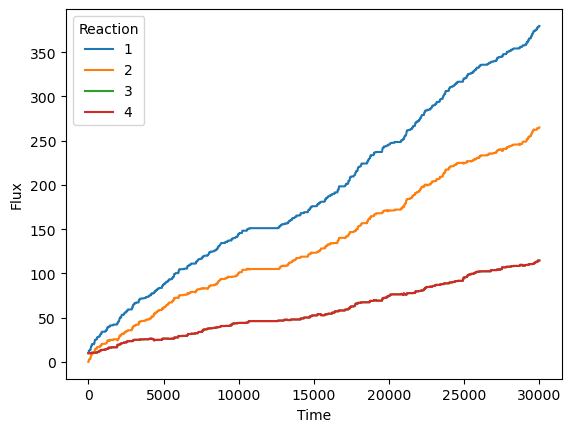

In [12]:
sns.lineplot(df_flux,x='Time',y='Flux',hue='Reaction')
plt.show()

### Normalized, rolling average change in flux across evolution.

This shows that an EvCM exists, as the direction of evolution is approximately constant.

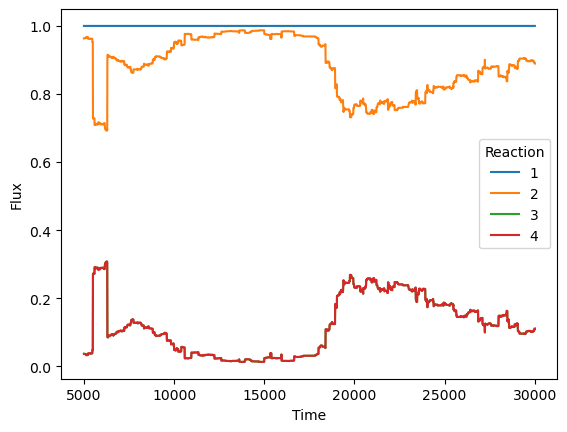

In [13]:
sns.lineplot(
df_flux_5gene.with_columns((pl.col('Flux').diff().rolling_mean(window_size=500)).over('Reaction')).\
        with_columns((pl.col('Flux')/pl.col('Flux').max()).over('Time')).drop_nulls(),
        x='Time',y='Flux',hue='Reaction')
plt.show()

## Comparison of the original toy network and the five gene version

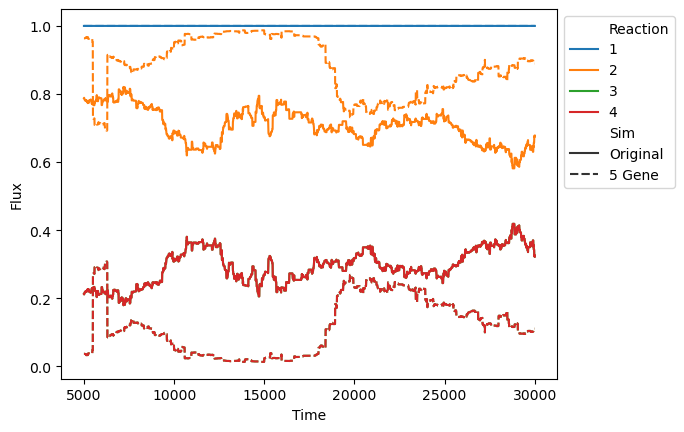

In [14]:
ax=sns.lineplot(
df_flux_5gene.with_columns((pl.col('Flux').diff().rolling_mean(window_size=500)).over('Reaction')).\
        with_columns((pl.col('Flux')/pl.col('Flux').max()).over('Time')).drop_nulls().with_columns(pl.lit('5 Gene').alias('Sim')),
        x='Time',y='Flux',hue='Reaction',style='Sim',style_order=['Original','5 Gene'],legend=False)
sns.lineplot(
df_flux.with_columns((pl.col('Flux').diff().rolling_mean(window_size=500)).over('Reaction')).\
        with_columns((pl.col('Flux')/pl.col('Flux').max()).over('Time')).drop_nulls().with_columns(pl.lit('Original').alias('Sim')),
        x='Time',y='Flux',hue='Reaction',style='Sim',style_order=['Original','5 Gene'],ax=ax)
sns.move_legend(ax,loc='upper left',bbox_to_anchor=(1,1))
plt.show()